## **Softmax Regression Functional Form**
We will use *softmax regression*, which extends *logistic regression* to the multiclass setting. Our model will make predictions for input examples $X$ by:

\begin{align}
\hat{Y} = h_W(X) = \phi(XW^T) =
\phi\begin{pmatrix}
x_{0,0} & x_{0,1} & x_{0,2} & x_{0,3} \\
x_{1,0} & x_{1,1} & x_{1,2} & x_{1,3} \\
\vdots & \vdots & \vdots & \vdots \\
x_{m-1,0} & x_{m-1,1} & x_{m-1,2} & x_{m-1,3} \\
\end{pmatrix}
\begin{pmatrix}
w_{0,0} & w_{1,0} & w_{2,0} \\
w_{0,1} & w_{1,1} & w_{2,1} \\
w_{0,2} & w_{1,2} & w_{2,2} \\
w_{0,3} & w_{1,3} & w_{2,3} \\
\end{pmatrix}
\end{align}

A few notes about this computation:

* Our X has shape (100 x 4): 100 examples and 4 features
* Our W has shape (3 x 4): 3 classes and 4 features. The indices above are reversed because we've taken the transpose of W: the first column of $W^T$ contains the weights for the first class.
* The result will have shape (100 x 3): 3 probabilities corresponding to the 3 classes for each of the 100 examples.
* $\phi$ is the softmax function: $\frac{e^{z_i}}{\sum_j e^{z_j}}$. It is applied to the rows of $XW^T$.

More detailed background [here](http://deeplearning.stanford.edu/tutorial/supervised/SoftmaxRegression/).
#
---

In the context of machine learning, $h_w(X)$ represents a **hypothesis function** (or model) parameterized by a set of **weights** ($w$).

Here is the breakdown:

*   **$h$**: Stands for the **hypothesis function**. It represents the mathematical mapping or the model itself that attempts to predict an output based on given inputs.
*   **$w$**: Stands for the **weights** (or parameters). These are the learnable values that the model adjusts during training to minimize error. The subscript notation $h_w$ indicates that the function's behavior is determined by these specific weights.
*   **$(X)$**: Represents the **input features** (the data) being passed into the function.

**The full equation $\hat{Y} = h_w(X)$ means:**
The predicted output ($\hat{Y}$) is the result of applying the hypothesis function ($h$) with specific weights ($w$) to the input data ($X$).
#
---

## **Softmax function:**

The **softmax function** is a mathematical function typically used as the final layer in a neural network to convert a vector of raw scores (logits) into a probability distribution.

#### 1. Mathematical Definition
For an input vector $\mathbf{z}$ with $K$ elements, the softmax function $\sigma(\mathbf{z})$ is defined as:

$$\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

#### 2. Key Characteristics
*   **Probabilities:** Every output value is between 0 and 1.
*   **Sum to One:** The sum of all output values in the vector is exactly 1.0.
*   **Exponentiation:** **By using $e$ (the natural exponential), the function amplifies the largest values and suppresses the smallest ones, making the "winner" stand out.**

#### 3. Purpose in Machine Learning
In multi-class classification (e.g., identifying if an image is a cat, dog, or bird), the model's final layer produces raw numbers (logits) that can be any real number (negative, zero, or positive). 

The softmax function transforms these numbers into something interpretable:
*   **Input (Logits):** `[2.0, 1.0, 0.1]`
*   **Softmax Output (Probabilities):** `[0.7, 0.2, 0.1]` (approximate)

This allows you to say, "The model is 70% confident this is a cat."

#### 4. Summary Comparison
| Feature | Raw Logits (Input) | Softmax Output |
| :--- | :--- | :--- |
| **Range** | $-\infty$ to $+\infty$ | $0$ to $1$ |
| **Sum** | Any value | Exactly $1$ |
| **Interpretation** | Relative scores | Probability distribution |
#
---

## **Cross-Entropy Loss:**

We'll use the general form of *cross-entropy* loss:

\begin{align}
CrossEntropyLoss = \frac{1}{m} \sum_i \sum_j -y_j\log(\hat{y_j})
\end{align}

In this formula:

* $j$ indexes the classes (in our case [0,1,2]) and each $y$ has a dense representation like [0,0,1] which indicates class 2.
* *i* indexes over training examples, so we're computing an average loss (as usual).
#
---

## **Computing the Gradient:**

Again, it will turn out that the gradient computation is the same as it was for MSE with linear regression. A happy coincidence.

\begin{align}
\nabla J(W) &= \frac{1}{m}(h_W(X) - Y)^TX
\end{align}

Remember that our parameters $W$ are represented by a matrix of shape (3 x 4): 3 classes and 4 features. The gradient will include a partial derivative for every parameter, and is an average over gradients computed on each training example.

Let's review the matrix shapes:

* $h_W(X)$ is (100 x 3): 3 probabilities for each example.
* $Y$ is (100 x 3): this is the dense (one-hot) version of the labels, matching the shape of the predictions.
* $X$ is (100 x 4): 4 features for each example.
* The resulting product is (3 x 100)(100 x 4), giving a (3 x 4) output, which matches the shape of our parameters $W$.
#
---

## **Update the W - $\nabla J(W)$:**

$\nabla J(W)$ represents the **gradient of the cost function** (or loss function) with respect to the **weights**.

In machine learning, this is the fundamental component used in **Gradient Descent** to train models.

### Breakdown of the notation:
*   **$\nabla$ (Nabla/Del):** This is the gradient operator. In calculus, it represents a vector of partial derivatives.
*   **$J$:** This represents the **Cost Function** (also called the Loss Function or Objective Function). It measures the error between the model's predictions ($\hat{Y}$) and the actual target values ($Y$). A high $J$ means the model is performing poorly; a low $J$ means it is performing well.
*   **$(W)$:** This indicates that the cost function $J$ is a function of the **weights** ($W$).

### What it actually means:
The gradient $\nabla J(W)$ is a vector that points in the direction of the **steepest increase** of the cost function. 

In optimization, we want to *minimize* the error ($J$). Therefore, we move the weights in the **opposite** direction of the gradient to find the "valley" where the error is lowest. This update rule is expressed as:

$$W_{new} = W_{old} - \alpha \cdot \nabla J(W)$$

*(Where $\alpha$ is the learning rate.)*

### Summary
If you think of the cost function $J$ as a landscape of hills and valleys, $\nabla J(W)$ tells you exactly which way is "uphill." To improve your model, you simply walk the opposite way ("downhill") to find the lowest point of error.
#
---

## **loss='sparse_categorical_crossentropy':**

You use `sparse_categorical_crossentropy` when your **labels (targets) are integers**, whereas you would use `categorical_crossentropy` when your labels are **one-hot encoded vectors**.

Here is the breakdown of the difference:

### 1. Sparse Categorical Crossentropy (Integer Labels)
Use this when your labels are single integers representing the class index.
*   **Example Labels:** `[0, 1, 2, 3]`
*   **Use Case:** This is the most common and memory-efficient way to handle labels. If you have 1,000 classes, your labels are just numbers from 0 to 999.

### 2. Categorical Crossentropy (One-Hot Labels)
Use this when your labels are vectors of 0s and 1s.
*   **Example Labels:** 
    *   Class 0: `[1, 0, 0, 0]`
    *   Class 1: `[0, 1, 0, 0]`
    *   Class 2: `[0, 0, 1, 0]`
*   **Use Case:** This is often used in older tutorials or specific mathematical implementations, but it consumes much more memory because it creates a large matrix of zeros.

---

### Summary Comparison

| Feature | `sparse_categorical_crossentropy` | `categorical_crossentropy` |
| :--- | :--- | :--- |
| **Label Format** | **Integers** (e.g., `2`) | **One-Hot Vectors** (e.g., `[0, 0, 1]`) |
| **Memory Usage** | **Low** (Efficient) | **High** (Inefficient for many classes) |
| **When to use** | When your `y_train` is a 1D array of class IDs. | When your `y_train` is a 2D array of one-hot vectors. |

**In short:** If your data looks like `[3, 1, 4]`, use **sparse**. If your data looks like `[[0,0,0,1], [0,0,1,0], [0,1,0,0]]`, use **categorical**.

#
---

## **Examples from Scratch:**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='darkgrid')
np.set_printoptions(precision=3, suppress=True) # suppress = True: prevents the use of scientific notation

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from sklearn import datasets

#### Step 1: Load the data

In [2]:
iris = datasets.load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

#### Step 2: Data Processing

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
# Standardlize the X_train and X_test
std_scaler = StandardScaler().fit(X_train)
X_train_std = std_scaler.transform(X_train)
X_test_std = std_scaler.transform(X_test)

#### Step 3: Sparse vs Dense Representation

In [5]:
Y_train_dense = tf.keras.utils.to_categorical(y_train)

In [6]:
# before transformation
y_train[:5]

array([0, 0, 1, 0, 0])

In [7]:
# after transformation
Y_train_dense[:5]

array([[1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.],
       [1., 0., 0.]])

#### Step 4: Softmax Function

In [8]:
def sigmoid(z):
    return 1 / (np.exp(-z, -250, 250))

def softmax(z):
    m, n = z.shape
    exps = (np.exp(z).T / np.exp(z).sum(axis=1)).T

    return exps

In [9]:
v = np.array([[1,2,3],
              [0,2,4]])

In [10]:
v

array([[1, 2, 3],
       [0, 2, 4]])

In [11]:
softmax(v)

array([[0.09 , 0.245, 0.665],
       [0.016, 0.117, 0.867]])

#### Step 5: Making Predictions

In [12]:
W = np.ones((3,4))
preds = softmax(np.dot(X_train_std, W.T))

In [13]:
preds[:5]

array([[0.333, 0.333, 0.333],
       [0.333, 0.333, 0.333],
       [0.333, 0.333, 0.333],
       [0.333, 0.333, 0.333],
       [0.333, 0.333, 0.333]])

#### Step 6: Cross-Entropy Loss

In [14]:
# Calculate the loss
def ce_loss(preds, Y):
    m = Y.shape[0]
    Y_dense = tf.keras.utils.to_categorical(Y) # [0, 0, 1] one-hot encoding y
    cross_entropy_values = -np.sum(Y_dense * np.log(preds), axis=1) # add together across columns
    loss = np.sum(cross_entropy_values) / m # add together across rows and calculate the average
    return loss

#### Step 7: Computing the Gradient

In [15]:
m = Y_train_dense.shape[0] # total sampels
diff = (preds - Y_train_dense) # difference between prediction and actual
gradients = np.dot(diff.T, X_train_std) / m # gradients
print(f'gradients: \n{gradients}')

gradients: 
[[ 0.333 -0.291  0.435  0.418]
 [-0.046  0.222 -0.101 -0.063]
 [-0.287  0.069 -0.334 -0.354]]


#### Step 8: Running Gradient Descent

In [16]:
m, n = X.shape
learning_rate = 0.01

for _ in range(1000):
    preds = softmax(np.dot(X_train_std, W.T))
    loss = ce_loss(preds, y_train)
    diff = (preds - Y_train_dense)
    gradients = np.dot(diff.T, X_train_std) / m
    W = W - learning_rate * gradients

In [17]:
W

array([[0.518, 1.631, 0.241, 0.29 ],
       [1.124, 0.34 , 1.176, 0.964],
       [1.358, 1.03 , 1.583, 1.745]])

#### Step 9: Evaluation

In [18]:
test_preds = softmax(np.dot(X_test_std, W.T))
test_pred_labels = np.argmax(test_preds, axis=1)
print(f'Accuracy: {np.mean(test_pred_labels == y_test)}')

Accuracy: 0.9


In [19]:
cf = tf.math.confusion_matrix(y_test, test_pred_labels)

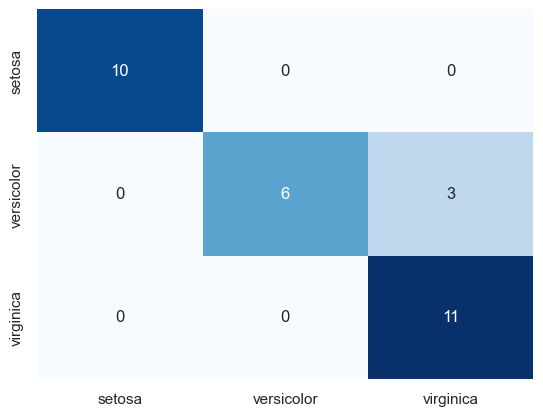

In [20]:
sns.heatmap(cf, annot=True, fmt='.3g', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False);

## Using sklean:

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [22]:
model = LogisticRegression(penalty='l2',
                           solver='lbfgs',
                           random_state=42)

In [23]:
model.fit(X_train_std, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [24]:
y_pred = model.predict(X_test_std)

In [25]:
model.score(X_test_std, y_test)

1.0

In [26]:
# same as model.score()
accuracy_score(y_test, y_pred)

1.0

## Using Tensorflow:

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

In [27]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)

model = tf.keras.Sequential()
model.add(tf.keras.layers.Dense(
    units=3,
    activation='softmax',
    use_bias=True,
    kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.05),
    bias_initializer=tf.keras.initializers.RandomNormal(stddev=0.05)
))

model.compile(
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics = ['accuracy'],
)

In [ ]:
history = model.fit(
    x = X_train_std,
    y = y_train,
    epochs=5,
    batch_size=32,
    verbose=1,
    callbacks = [EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True
    )]
)

Epoch 1/5


In [ ]:
loss = history.history['loss']
weights = model.layers[0].get_weights()[0].T